In [1]:
import itertools

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import xarray as xr

In [2]:
az.style.use("arviz-variat")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = 0.94
SEED = 128

In [3]:
trials = 4
theta_real = 0.35 # unknown value in a real experiment
data = pz.Binomial(n=1, p=theta_real).rvs(trials, random_state=128)
data

array([1, 0, 0, 0])

In [4]:
with pm.Model() as our_first_model:
    θ = pm.Beta('θ', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=θ, observed=data)
    idata = pm.sample(2000, random_seed=4591)

NUTS[nutpie]: [θ]


Output()

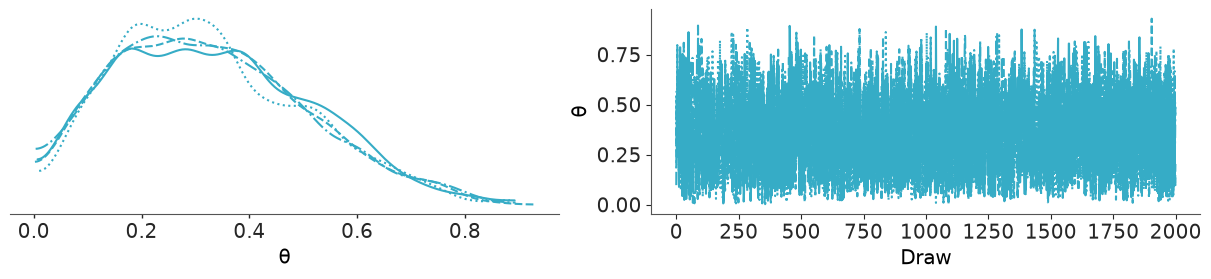

In [5]:
az.plot_trace_dist(idata);

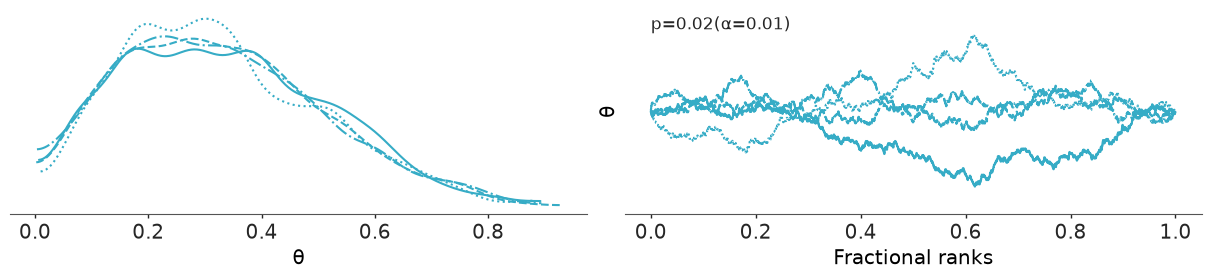

In [6]:
az.plot_rank_dist(idata);

In [7]:
az.summary(idata, kind="stats")

,mean,sd,hdi94_lb,hdi94_ub
θ,0.33,0.18,0.022,0.64


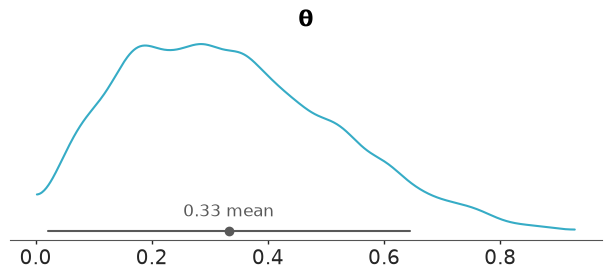

In [8]:
az.plot_dist(idata);

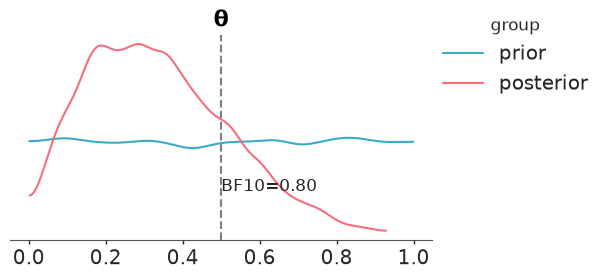

In [9]:
dt_bf = idata.copy(deep=True)
rng = np.random.default_rng(301)

prior = xr.Dataset({"θ": (("chain", "draw"),
                          rng.uniform(0, 1, size=(4, 2500)))})
dt_bf["prior"] = prior

az.plot_bf(dt_bf, var_names="θ", ref_val=0.5);

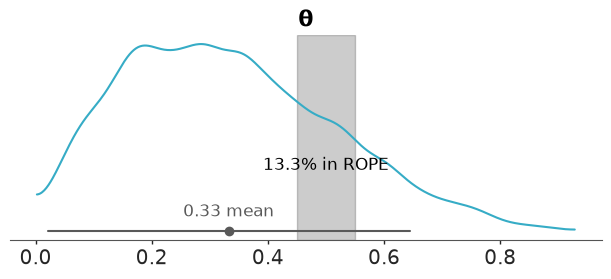

In [10]:
az.plot_dist(idata, rope=[0.45, .55]);

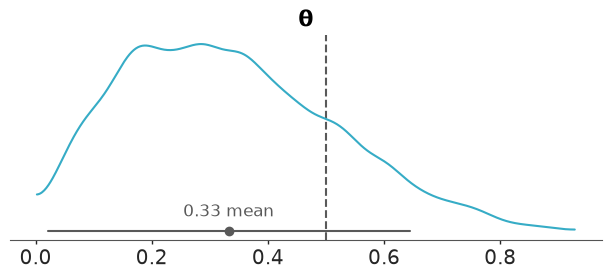

In [11]:
pc = az.plot_dist(idata)
az.add_lines(pc, values=0.5);

In [12]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
np.argmin(lossf_a)

np.int64(62)

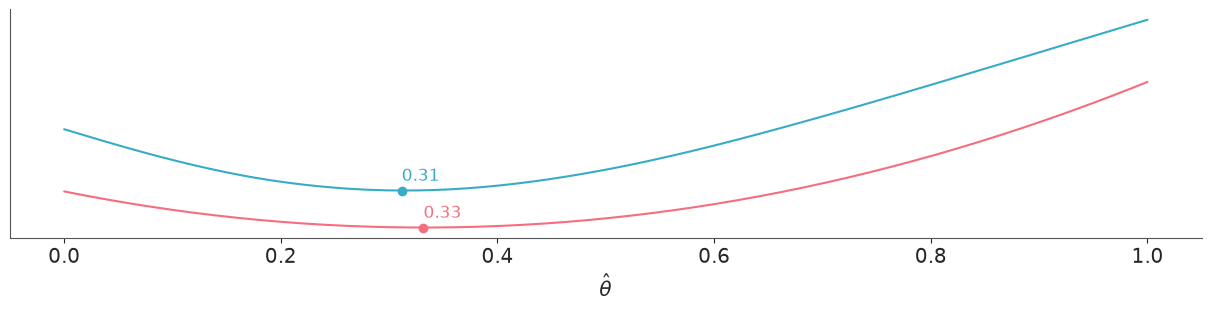

In [13]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]),
    (grid[mini], lossf[mini] + 0.03), color=c)

    ax.set(yticks=([]), xlabel=r'$\hat \theta$')

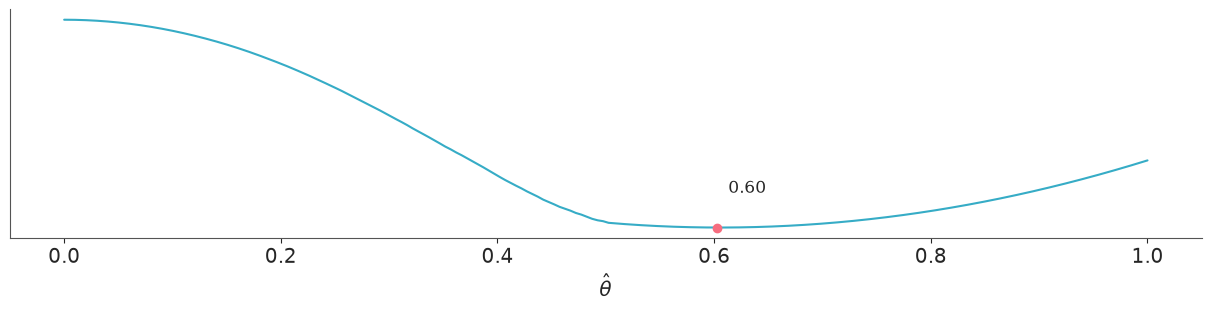

In [14]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(θ_pos / np.abs(i**2 - θ_pos))
    else:
        f = np.mean((i - θ_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)
mini = np.argmin(lossf)
_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]),
(grid[mini] + 0.01, lossf[mini] + 0.1))
ax.set(yticks=[], xlabel=r'$\hat \theta$');

/tmp/ipykernel_65026/1943184378.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False);


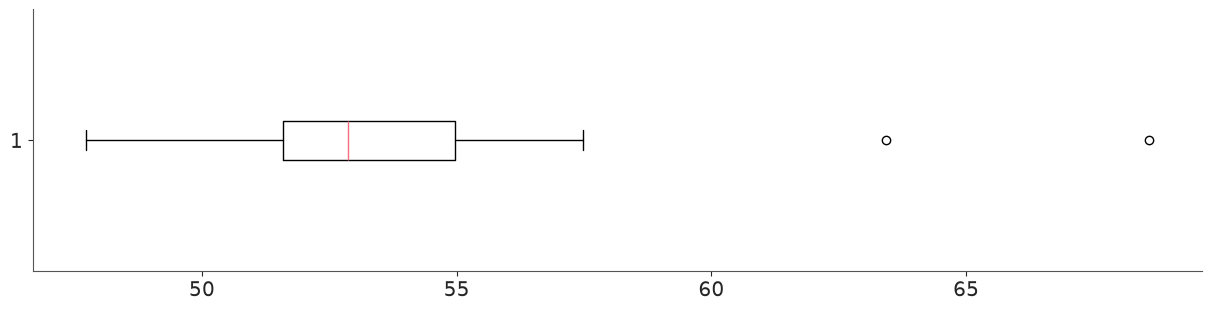

In [15]:
data = np.loadtxt("data/chemical_shifts.csv")
_, ax = plt.subplots(figsize=(12, 3))
ax.boxplot(data, vert=False);

In [16]:
with pm.Model() as model_g:
    μ = pm.Uniform('μ', lower=40, upper=70)
    σ = pm.HalfNormal('σ', sigma=5)
    Y = pm.Normal('Y', mu=μ, sigma=σ, observed=data)
    idata_g = pm.sample(random_seed=4591)

NUTS[nutpie]: [μ, σ]


Output()

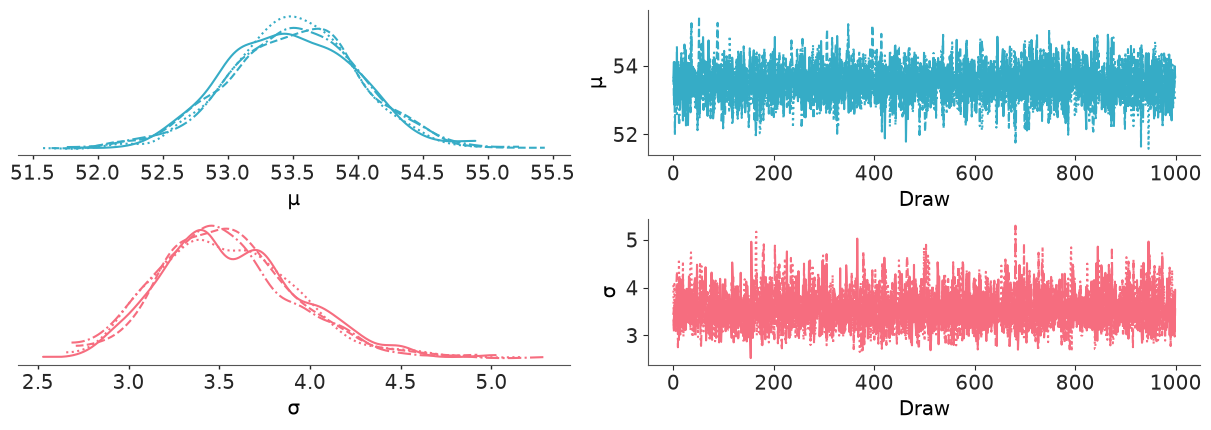

In [17]:
az.plot_trace_dist(idata_g);

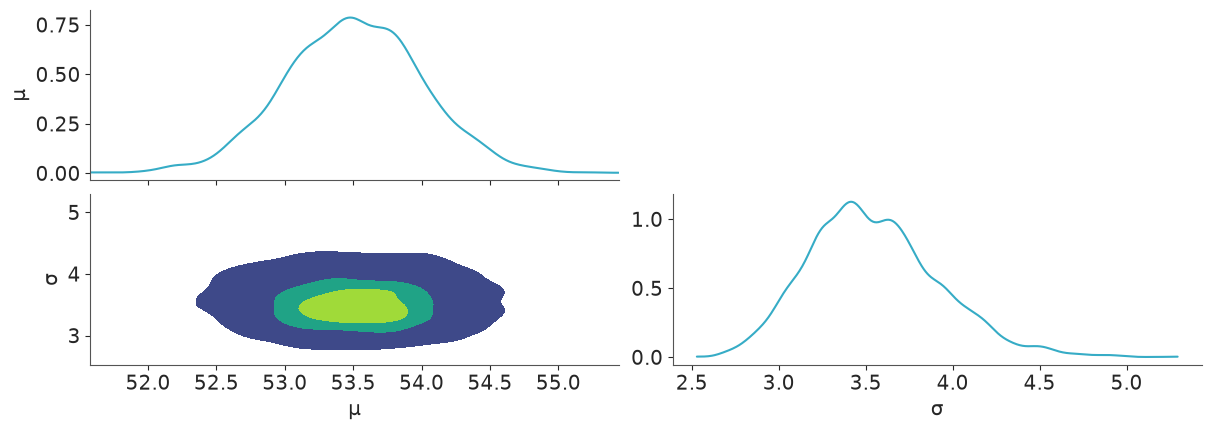

In [18]:
az.plot_pair(idata_g,
             visuals={"scatter":False,
                      "contourf":True}
             );

In [19]:
az.summary(idata_g, kind="stats")

,mean,sd,hdi94_lb,hdi94_ub
μ,54,0.5,53,54
σ,3.5,0.38,2.9,4.2


In [20]:
pm.sample_posterior_predictive(idata_g, model=model_g, extend_inferencedata=True, random_seed=4591)


Sampling: [Y]


Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           μ        (chain, draw) float64 32kB 53.67 54.11 52.86 ... 53.56 53.56 53.56
│           σ        (chain, draw) float64 32kB 3.319 3.127 3.587 ... 3.16 3.16 3.16
│       Attributes:
│           created_at:                 2026-09-18T13:22:24.040674+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.12042427062988281
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 2 1 2 2 2 ... 1 2 1 1 1
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.014 1.156 ... 0.9676
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.079 1.079 ... 1.042
│           mean_tree_accept          (chain, draw) float64 32kB 0.8971 ... 0.6992
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.02966 ... 0.01457
│           transformation_index      (chain, draw) int64 32kB 337 337 337 ... 337 337
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-18T13:22:24.020544+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-18T13:22:24.036630+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:  (Y_dim_0: 48)
│       Coordinates:
│         * Y_dim_0  (Y_dim_0) int64 384B 0 1 2 3 4 5 6 7 8 ... 40 41 42 43 44 45 46 47
│       Data variables:
│           Y        (Y_dim_0) float64 384B 51.06 55.12 53.73 50.24 ... 54.3 53.84 53.16
│       Attributes:
│           created_at:                 2026-09-18T13:22:26.564677+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                []
└── Group: /posterior_predictive
        Dimensions:  (chain: 4, draw: 1000, Y_dim_0: 48)
        Coordinates:
          * chain    (chain) int64 32B 0 1 2 3
  

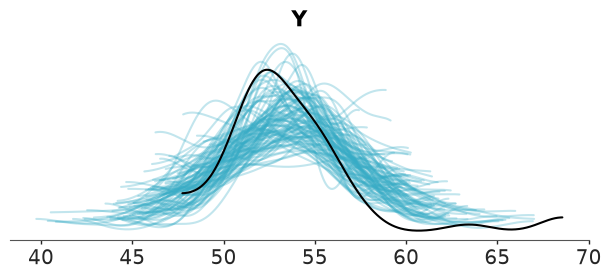

In [21]:
az.plot_ppc_dist(idata_g, num_samples=100, kind="kde");

<>:6: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:6: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_65026/3607327898.py:6: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  legend="StudentT(nu=$\infty$, mu=0, sigma=1)")


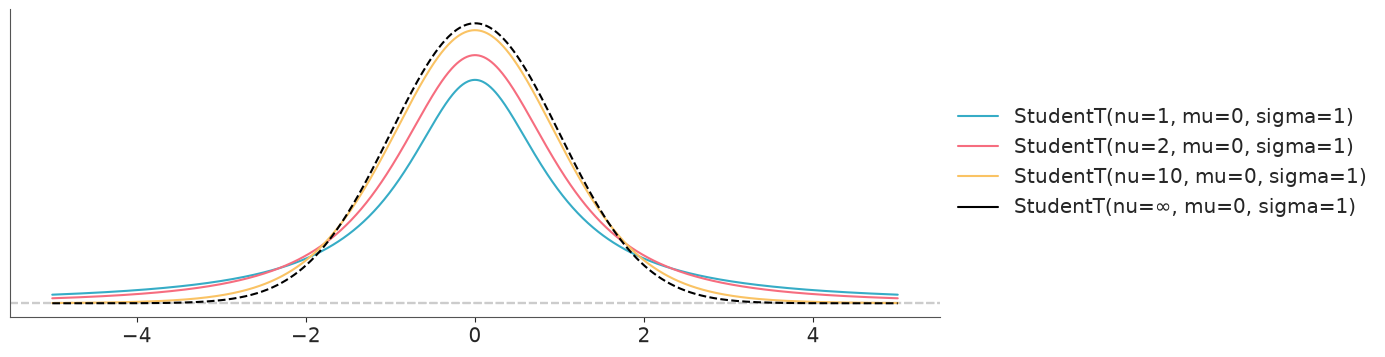

In [22]:
_, ax = plt.subplots(figsize=(12, 4))
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5), ax=ax)

pz.Normal(0, 1).plot_pdf(support=(-5, 5), color="k", ax=ax,
                         legend="StudentT(nu=$\infty$, mu=0, sigma=1)")
ax.get_lines()[-1].set_linestyle("--")

In [23]:
with pm.Model() as model_t:
    μ = pm.Uniform('μ', 40, 75)
    σ = pm.HalfNormal('σ', sigma=10)
    ν = pm.Exponential('ν', 1/30)
    y = pm.StudentT('y', nu=ν, mu=μ, sigma=σ, observed=data)
    idata_t = pm.sample(random_seed=4591)

NUTS[nutpie]: [μ, σ, ν]


Output()

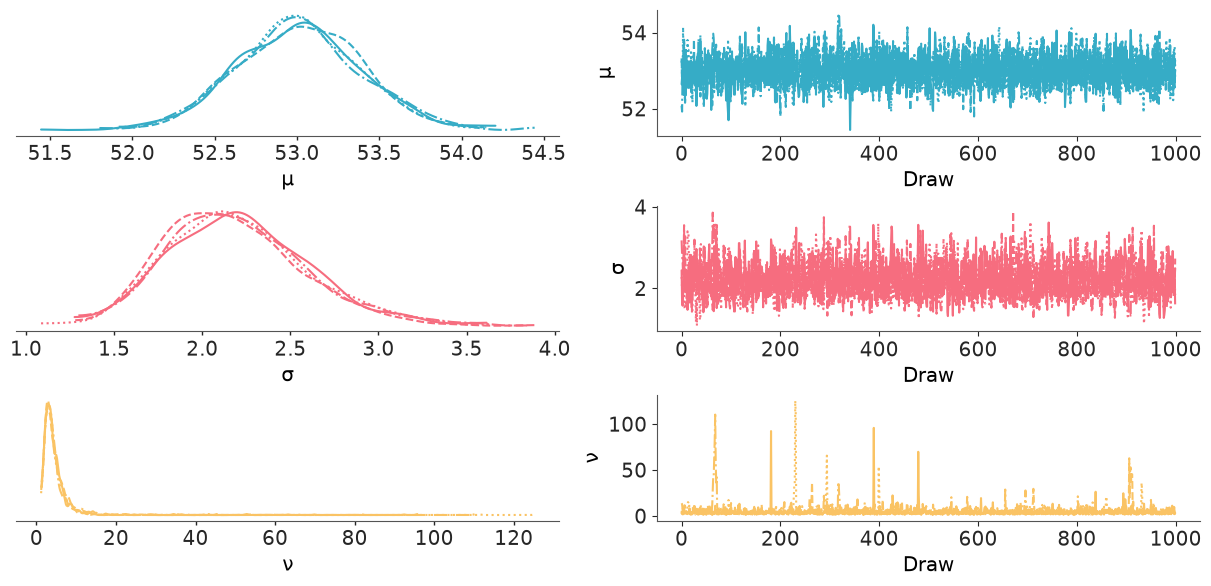

In [24]:
az.plot_trace_dist(idata_t);

In [25]:
az.summary(idata_t, kind="stats", round_to=2)

,mean,sd,hdi94_lb,hdi94_ub
μ,53.01,0.38,52.34,53.76
σ,2.20,0.40,1.50,2.97
ν,4.76,5.71,1.19,9.07


Sampling: [y]


Output()

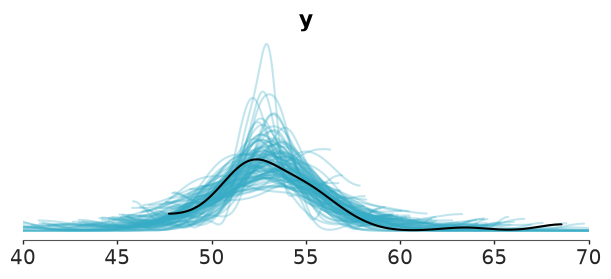

In [26]:
pm.sample_posterior_predictive(idata_t, model=model_t, extend_inferencedata=True, random_seed=123)
pc = az.plot_ppc_dist(idata_t, num_samples=100, kind="kde")
pc.get_viz("plot").set_xlim(40, 70);

In [27]:
idata_g

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           μ        (chain, draw) float64 32kB 53.67 54.11 52.86 ... 53.56 53.56 53.56
│           σ        (chain, draw) float64 32kB 3.319 3.127 3.587 ... 3.16 3.16 3.16
│       Attributes:
│           created_at:                 2026-09-18T13:22:24.040674+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.12042427062988281
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 2 1 2 2 2 ... 1 2 1 1 1
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.014 1.156 ... 0.9676
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.079 1.079 ... 1.042
│           mean_tree_accept          (chain, draw) float64 32kB 0.8971 ... 0.6992
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.02966 ... 0.01457
│           transformation_index      (chain, draw) int64 32kB 337 337 337 ... 337 337
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-18T13:22:24.020544+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-18T13:22:24.036630+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:  (Y_dim_0: 48)
│       Coordinates:
│         * Y_dim_0  (Y_dim_0) int64 384B 0 1 2 3 4 5 6 7 8 ... 40 41 42 43 44 45 46 47
│       Data variables:
│           Y        (Y_dim_0) float64 384B 51.06 55.12 53.73 50.24 ... 54.3 53.84 53.16
│       Attributes:
│           created_at:                 2026-09-18T13:22:26.564677+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                []
└── Group: /posterior_predictive
        Dimensions:  (chain: 4, draw: 1000, Y_dim_0: 48)
        Coordinates:
          * chain    (chain) int64 32B 0 1 2 3
  

In [28]:
posterior = idata_g.posterior

In [29]:
posterior.sel(draw=0, chain=[0, 2])

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  (chain: 2)
    Coordinates:
      * chain    (chain) int64 16B 0 2
        draw     int64 8B 0
    Data variables:
        μ        (chain) float64 16B 53.67 53.54
        σ        (chain) float64 16B 3.319 4.053
    Attributes:
        created_at:                 2026-09-18T13:22:24.040674+00:00
        creation_library:           ArviZ
        creation_library_version:   1.3.0
        creation_library_language:  Python
        sample_dims:                ['chain', 'draw']
        inference_library:          nutpie
        inference_library_version:  0.16.11
        sampling_time:              0.12042427062988281
        tuning_steps:               400

In [30]:
posterior.mean()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        μ        float64 8B 53.51
        σ        float64 8B 3.548
    Attributes:
        created_at:                 2026-09-18T13:22:24.040674+00:00
        creation_library:           ArviZ
        creation_library_version:   1.3.0
        creation_library_language:  Python
        sample_dims:                ['chain', 'draw']
        inference_library:          nutpie
        inference_library_version:  0.16.11
        sampling_time:              0.12042427062988281
        tuning_steps:               400

In [31]:
posterior.mean("draw")

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  (chain: 4)
    Coordinates:
      * chain    (chain) int64 32B 0 1 2 3
    Data variables:
        μ        (chain) float64 32B 53.48 53.51 53.5 53.53
        σ        (chain) float64 32B 3.571 3.558 3.547 3.514
    Attributes:
        created_at:                 2026-09-18T13:22:24.040674+00:00
        creation_library:           ArviZ
        creation_library_version:   1.3.0
        creation_library_language:  Python
        sample_dims:                ['chain', 'draw']
        inference_library:          nutpie
        inference_library_version:  0.16.11
        sampling_time:              0.12042427062988281
        tuning_steps:               400

In [32]:
stacked = az.extract(idata_g)

## Comparaing groups

In [33]:
tips = pd.read_csv("data/tips.csv")
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [34]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


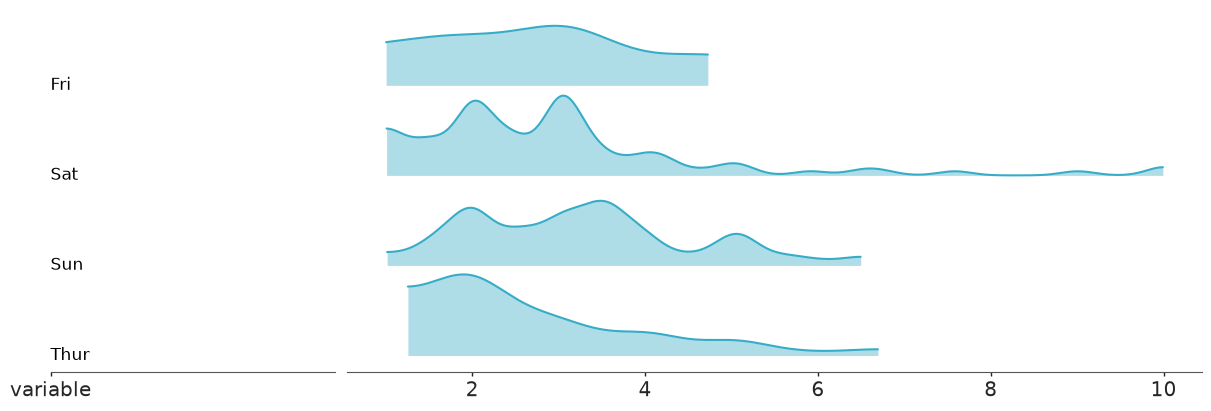

In [35]:
data = tips.pivot(columns="day", values="tip").rename_axis("draw")

dt = xr.DataTree.from_dict({
    "posterior": xr.Dataset.from_dataframe(data)
})

pc = az.plot_ridge(
    dt,
    kind="kde",
    sample_dims=["draw"],
    figure_kwargs={"figsize": (12, 4)},
)

In [36]:
categories = np.array(["Thur", "Fri", "Sat", "Sun"])

tip = tips["tip"].values
idx = pd.Categorical(tips["day"], categories=categories).codes

In [37]:
coords = {"days": categories, "days_flat":categories[idx]}

with pm.Model(coords=coords) as comparing_groups:
    μ = pm.HalfNormal("μ", sigma=5, dims="days")
    σ = pm.HalfNormal("σ", sigma=1, dims="days")

    y = pm.Gamma("y", mu=μ[idx], sigma=σ[idx], observed=tip, dims="days_flat")

    idata_cg = pm.sample(random_seed=4591)
    pm.sample_posterior_predictive(idata_cg, extend_inferencedata=True,
                                   random_seed=4591)

NUTS[nutpie]: [μ, σ]


Output()

Sampling: [y]


Output()

In [38]:
idata_cg["posterior_predictive"].data_vars

Data variables:
    y        (chain, draw, days_flat) float64 8MB 2.473 2.861 ... 2.632 1.294

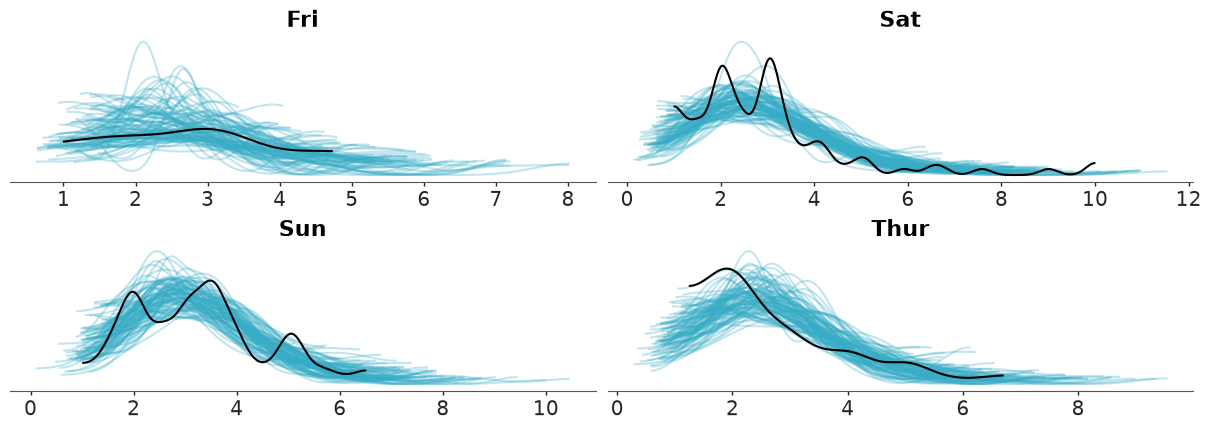

In [39]:
pc = az.plot_ppc_dist(
    idata_cg,
    var_names=["y"],
    cols=["days_flat"],
    kind="kde",
    col_wrap=2,
    num_samples=100,
)

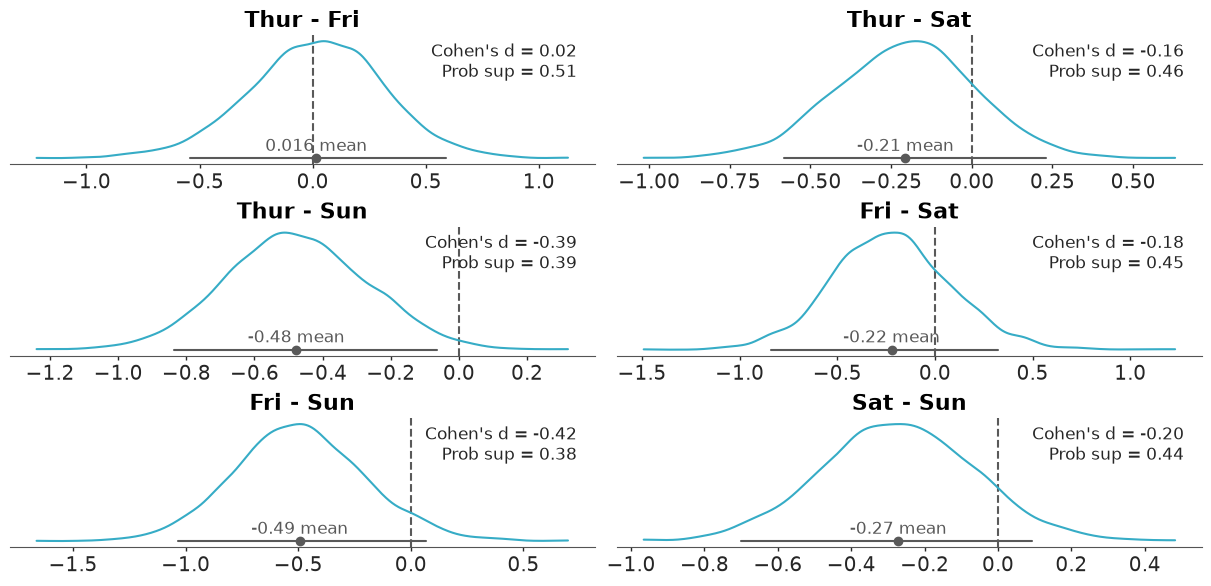

In [40]:
cg_posterior = az.extract(idata_cg)
mu, sigma = cg_posterior["μ"], cg_posterior["σ"]

pairs = list(itertools.combinations(categories, 2))
labels = [f"{a} - {b}" for a, b in pairs]

diffs, ds_ = [], []
for a, b in pairs:
    diff = mu.sel(days=a) - mu.sel(days=b)
    diffs.append(diff)
    ds_.append(diff / np.sqrt((sigma.sel(days=a)**2 + sigma.sel(days=b)**2) / 2))

means_diff = xr.concat(diffs, dim="comparison").assign_coords(comparison=labels)
d_cohen = xr.concat(ds_, dim="comparison").assign_coords(comparison=labels).mean("sample")
ps = pz.Normal(0, 1).cdf(d_cohen / np.sqrt(2))


annotation = xr.DataArray(
    [f"Cohen's d = {d:.2f}\nProb sup = {p:.2f}" for d, p in zip(d_cohen.values, ps)],
    dims="comparison",
    coords={"comparison": labels},
    name="annotation",
)

def add_annotation(da, target):
    target.text(0.97, 0.95, da.item(),
                transform=target.transAxes, 
                ha="right", va="top")

pc = az.plot_dist(
    xr.Dataset({"means_diff": means_diff}),
    sample_dims=["sample"],
    cols=["comparison"],
    col_wrap=2,
)
az.add_lines(pc, values=0, color="black", linestyle="--")
pc.map(add_annotation, data=annotation)